# XGBoost Cross-Sectional Return Predictor

Walk-forward backtest using XGBoost on the full S&P 500 universe.
Results (charts + tables) are saved to .

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
sys.path.insert(0, '../../src')

from evaluation import WalkForwardBacktester
from models import XGBoostRankModel
import feature_engineer
import utils

## 1  Data Loading

In [2]:
df = pd.read_parquet("../../data/raw/yahoo_raw.parquet")
df = df.stack(level="Ticker", future_stack=True).reset_index()
df = df.sort_values(["Ticker", "Date"]).set_index("Date")
df.columns.name = None
print(f"Loaded {df['Ticker'].nunique()} tickers, {len(df):,} rows")
df.head()

Loaded 503 tickers, 3,192,541 rows


,Ticker,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,,
2001-01-02,A,30.340164,36.391273,38.537197,35.094776,38.537197,2261684.0
2001-01-03,A,33.471104,40.146637,40.414879,34.021816,35.139484,4502678.0
2001-01-04,A,34.738392,41.666668,42.694920,39.565453,40.683121,4398388.0
2001-01-05,A,32.837448,39.386623,41.666668,38.268955,40.951359,3277052.0
2001-01-08,A,31.756531,38.090130,39.878399,37.419529,38.805435,2273288.0


## 2  Feature Engineering

In [3]:
FEATURE_CONFIG = {
    "mom_windows":  [(1, 5), (1, 21), (21, 126), (21, 252), (126, 252), (252, 756)],
    "vol_windows":  [21, 63, 252],
    "liq_windows":  [21, 63],
    "high_windows": [252],
    "max_windows":  [21],
}

FEATURE_COLS = [
    "mom_1_5", "mom_1_21", "mom_21_126", "mom_21_252", "mom_126_252", "mom_252_756",
    "vol_21", "downside_dev_21", "vol_63", "downside_dev_63", "vol_252", "downside_dev_252",
    "dollar_volume_21", "dollar_volume_63",
    "dist_252_high", "max_21",
]

df = feature_engineer.compute_momentum_features(df, FEATURE_CONFIG["mom_windows"])
df = feature_engineer.compute_volatility_features(df, FEATURE_CONFIG["vol_windows"])
df = feature_engineer.compute_liquidity(df, FEATURE_CONFIG["liq_windows"])
df = feature_engineer.compute_extreme_features(
    df, high_windows=FEATURE_CONFIG["high_windows"], max_windows=FEATURE_CONFIG["max_windows"]
)
print("Features computed.")

/Users/thiago/Documents/cross_sectional_return_prediction/notebooks/models/../../src/feature_engineer.py:23: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = df.groupby("Ticker")["Adj Close"].pct_change()
/Users/thiago/Documents/cross_sectional_return_prediction/notebooks/models/../../src/feature_engineer.py:57: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = g_price.pct_change()


Features computed.


## 3  Target Construction

Forward 21-day cross-sectional rank (pct rank across all stocks at each date).

In [ ]:
df["fwd_return_21"] = (
    df.groupby("Ticker")["Adj Close"]
    .pct_change(21)
    .shift(-21)
)

df["target"] = df.groupby("Date")["fwd_return_21"].rank(pct=True)

# Cross-sectionally rank features to remove outlier sensitivity
df[FEATURE_COLS] = df.groupby("Date")[FEATURE_COLS].rank(pct=True)

# Trim to dates where the longest-window feature is available
t0 = df.reset_index().groupby("Date")["mom_252_756"].count()
t0 = t0[t0 >= 1].index[0]
df = df[df.index > t0]

print(f"Panel shape after trim: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")

/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67830/3000263045.py:2: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df.groupby("Ticker")["Adj Close"]


Panel shape after trim: (2811770, 25)
Date range: 2004-01-09 → 2026-03-30


In [10]:
df_new = pd.read_parquet("../../data/processed/processed.parquet")
FEATURE_COLS_NEW = [
    "mom_1_5", "mom_1_21", "mom_126_252", "mom_252_756", "vol_21", "vol_63", "vol_252", "dollar_volume_21", 
    "dist_252_high", "skew_252", 'rolling_beta']

## 4  Walk-Forward Backtest

In [11]:
MODEL_NAME = "xgboost_new"
RESULTS_DIR = "../results/xgboost_new"

model = XGBoostRankModel(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.2,
    min_child_weight=100,
    gamma=0.5,
)

backtester = WalkForwardBacktester(
    model=model,
    initial_train_months=84,   # 7-year expanding window
    test_months=12,
    step_months=1,
    embargo_days=21,
)

results = backtester.run(df_new, feature_cols=FEATURE_COLS_NEW, target_col="target")
print(f"Completed {len(results)} folds.")

Walk-forward [xgboost]: 100%|██████████| 183/183 [05:12<00:00,  1.71s/it]

Completed 182 folds.


## 5  Fold Summary

In [12]:
fold_summary = backtester.summary(results)
print(fold_summary.to_string(index=False))

 fold train_start  train_end test_start   test_end  n_test_obs
    0  2004-01-12 2010-12-13 2011-01-12 2012-01-12      110635
    1  2004-01-12 2011-01-12 2011-02-11 2012-02-13      110785
    2  2004-01-12 2011-02-11 2011-03-15 2012-03-14      110931
    3  2004-01-12 2011-03-15 2011-04-13 2012-04-13      111034
    4  2004-01-12 2011-04-13 2011-05-13 2012-05-14      111139
    5  2004-01-12 2011-05-13 2011-06-14 2012-06-13      111281
    6  2004-01-12 2011-06-14 2011-07-14 2012-07-13      111425
    7  2004-01-12 2011-07-14 2011-08-12 2012-08-13      111588
    8  2004-01-12 2011-08-12 2011-09-13 2012-09-12      111756
    9  2004-01-12 2011-09-13 2011-10-12 2012-10-11      111924
   10  2004-01-12 2011-10-12 2011-11-10 2012-11-13      112113
   11  2004-01-12 2011-11-10 2011-12-12 2012-12-13      112287
   12  2004-01-12 2011-12-12 2012-01-12 2013-01-15      112464
   13  2004-01-12 2012-01-12 2012-02-13 2013-02-14      112678
   14  2004-01-12 2012-02-13 2012-03-14 2013-03-18     

## 6  Diagnostics — IC, ICIR, L/S Spread

    CROSS-SECTIONAL DIAGNOSTIC  [XGBOOST_NEW]
  Period:            2011-01-12 → 2026-02-25
  # Cross-sections:  182

  Mean IC:           0.0331
  IC Std:            0.1566
  ICIR:              0.2113
  IC t-stat (NW):    3.53  (p=0.0005)
  Hit Rate:          61.0%  (% months IC > 0)

  Mean L/S Spread:   0.0292  (rank units)
  L/S Hit Rate:      59.9%

  ✓ IC is statistically significant (NW |t| > 2)
  ~ Mean IC 0.02–0.05 — acceptable, typical in practice
  ~ ICIR < 0.5 — high variability in monthly performance

  Charts saved to ../results/xgboost_new/charts
  Tables saved to ../results/xgboost_new/tables


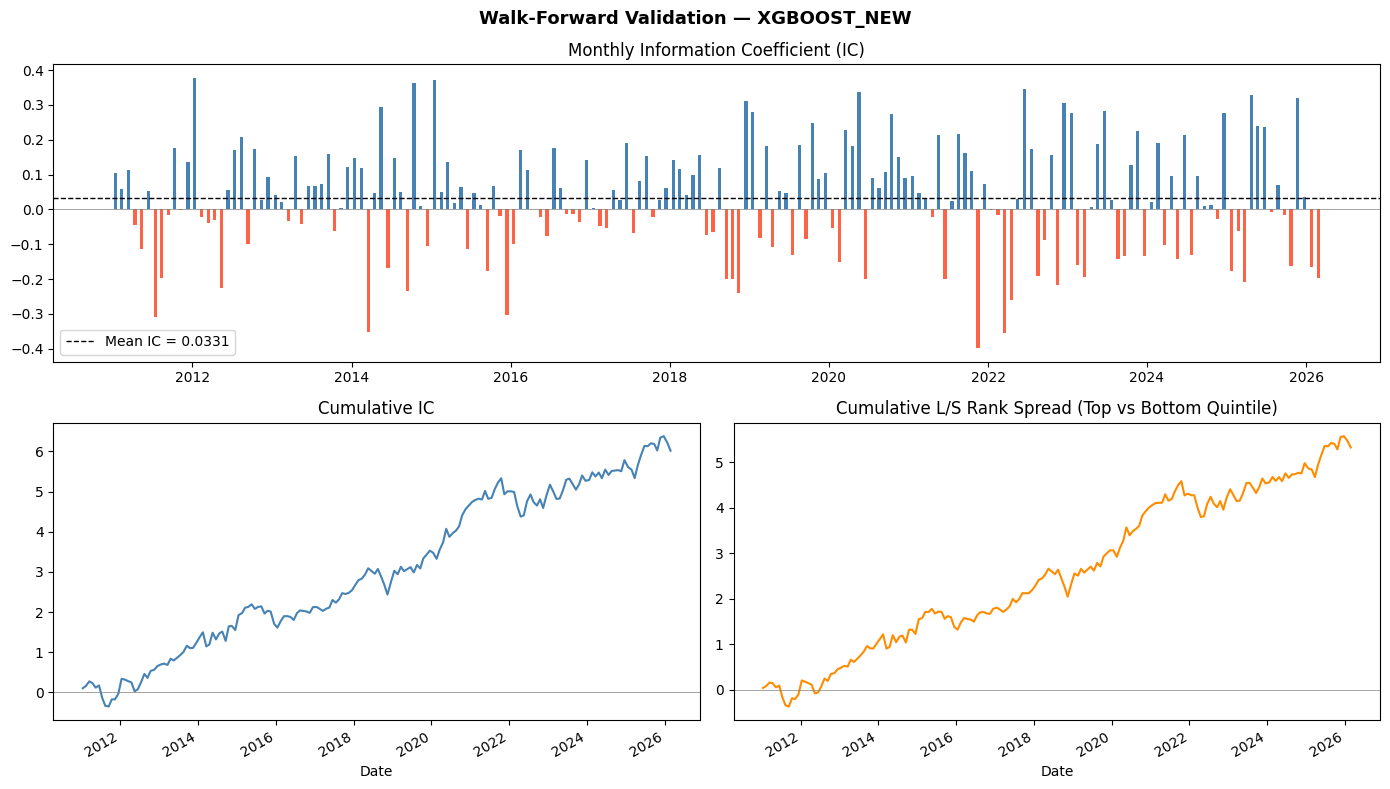

In [13]:
ic_series, ls_spread = utils.diagnose(
    results,
    ic_on_every=21,
    save_dir=RESULTS_DIR,
    model_name=MODEL_NAME,
)

## 7  Feature Importance

Aggregate XGBoost feature importance across all folds (average gain).

  Feature importance chart saved to ../results/xgboost_new/charts


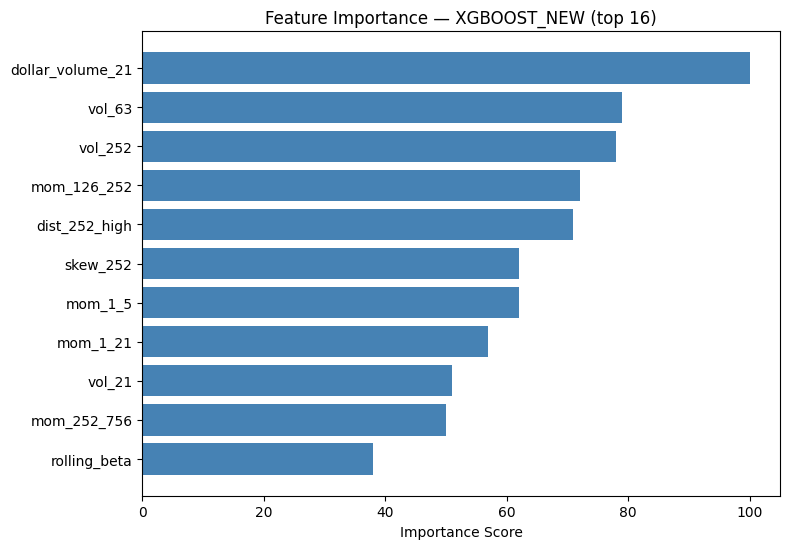

In [14]:
from models import XGBoostRankModel
import xgboost as xgb
import pandas as pd

# Re-run one final model on the full dataset to get stable importances
# (last fold model is already in  after the walk-forward)
all_importances = []
for r in results:
    # We stored the model per fold — use the last model for a quick estimate
    pass

# Use the model from the final fold (already fitted)
importance = model.get_feature_importance()
if importance is not None:
    fig = utils.plot_feature_importance(
        importance,
        model_name=MODEL_NAME,
        top_n=len(FEATURE_COLS),
        save_dir=RESULTS_DIR,
    )
    plt.show()
else:
    print("No feature importances available.")

## 8  Per-Fold IC Summary

 fold test_start   mean_ic
    0 2011-01-12  0.029293
    1 2011-02-11  0.013401
    2 2011-03-15  0.012593
    3 2011-04-13 -0.000989
    4 2011-05-13 -0.020589
    5 2011-06-14 -0.003067
    6 2011-07-14  0.011133
    7 2011-08-12  0.051743
    8 2011-09-13  0.049557
    9 2011-10-12  0.060771
   10 2011-11-10  0.060152
   11 2011-12-12  0.062663
   12 2012-01-12  0.059544
   13 2012-02-13  0.034111
   14 2012-03-14  0.030176
   15 2012-04-13  0.046232
   16 2012-05-14  0.042596
   17 2012-06-13  0.054637
   18 2012-07-13  0.047843
   19 2012-08-13  0.041764
   20 2012-09-12  0.051532
   21 2012-10-11  0.061371
   22 2012-11-13  0.038775
   23 2012-12-13  0.048493
   24 2013-01-15  0.053370
   25 2013-02-14  0.067001
   26 2013-03-18  0.032024
   27 2013-04-17  0.044918
   28 2013-05-16  0.047621
   29 2013-06-17  0.042888
   30 2013-07-17  0.049903
   31 2013-08-15  0.049388
   32 2013-09-16  0.029493
   33 2013-10-15  0.045897
   34 2013-11-13  0.049980
   35 2013-12-13  0.033399
 

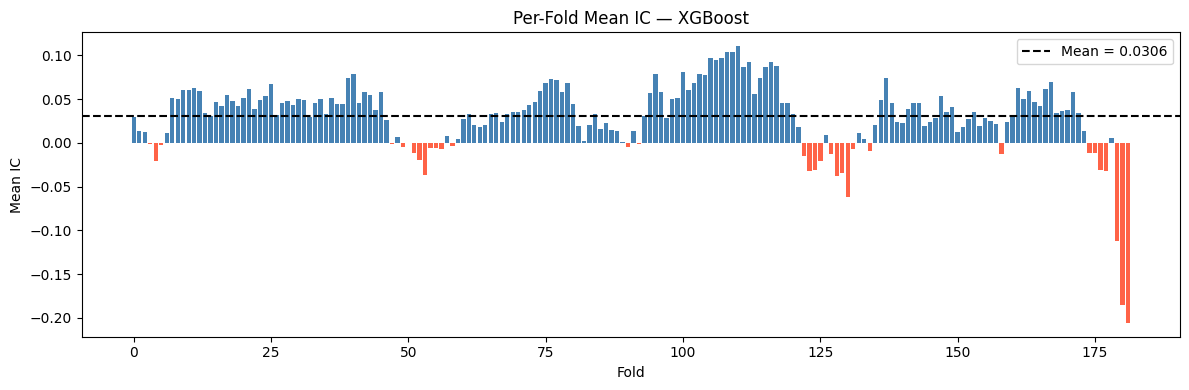

In [15]:
import matplotlib.pyplot as plt

fold_ics = []
for r in results:
    import pandas as pd
    from scipy.stats import spearmanr
    df_fold = pd.DataFrame({"pred": r["preds"], "actual": r["actuals"]}, index=r["index"])
    sampled = df_fold.index.unique().sort_values()[::21]
    df_s = df_fold[df_fold.index.isin(sampled)]
    ic = df_s.groupby("Date").apply(lambda x: x["pred"].corr(x["actual"], method="spearman")).mean()
    fold_ics.append({"fold": r["fold"], "test_start": r["test_start"], "mean_ic": ic})

fold_ic_df = pd.DataFrame(fold_ics)
print(fold_ic_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["steelblue" if v > 0 else "tomato" for v in fold_ic_df["mean_ic"]]
ax.bar(fold_ic_df["fold"], fold_ic_df["mean_ic"], color=colors)
ax.axhline(fold_ic_df["mean_ic"].mean(), color="black", linestyle="--",
           label=f'Mean = {fold_ic_df["mean_ic"].mean():.4f}')
ax.set_xlabel("Fold")
ax.set_ylabel("Mean IC")
ax.set_title("Per-Fold Mean IC — XGBoost")
ax.legend()
plt.tight_layout()

import pathlib
pathlib.Path(f"{RESULTS_DIR}/charts").mkdir(parents=True, exist_ok=True)
fig.savefig(f"{RESULTS_DIR}/charts/xgboost_per_fold_ic.png", dpi=150, bbox_inches="tight")
fold_ic_df.to_csv(f"{RESULTS_DIR}/tables/xgboost_per_fold_ic.csv", index=False)
plt.show()